<a href="https://colab.research.google.com/github/kisob/pizza-sales-task3/blob/main/MLnotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Model Comparison for Insurance Charges Prediction

This notebook aims to demonstrate and compare various machine learning models for predicting insurance charges based on the provided `insurance_cleaned_unscaled.csv` dataset. We will cover data loading, exploratory data analysis, model training, evaluation, and finally, recommend a suitable model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/insurance_cleaned_unscaled.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


## 1. Data Overview and Exploration (EDA)
Let's get a general understanding of the dataset, including its structure, data types, and summary statistics. This will help us identify potential issues like missing values or incorrect data types.

In [2]:
# Display concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   sex               1337 non-null   int64  
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   smoker            1337 non-null   int64  
 5   charges           1337 non-null   float64
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 66.7 KB

Descriptive Statistics:


,age,sex,bmi,children,smoker,charges
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,0.504862,30.663452,1.095737,0.204936,13279.121487
std,14.044333,0.500163,6.100468,1.205571,0.403806,12110.359656
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.290000,0.000000,0.000000,4746.344000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,9386.161300
75%,51.000000,1.000000,34.700000,2.000000,0.000000,16657.717450
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


In [3]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
age,0
sex,0
bmi,0
children,0
smoker,0
charges,0
region_northwest,0
region_southeast,0
region_southwest,0


### Distribution of Target Variable: `charges`
Understanding the distribution of the target variable is crucial for regression tasks. It can inform us about the nature of the data and potential transformations needed.

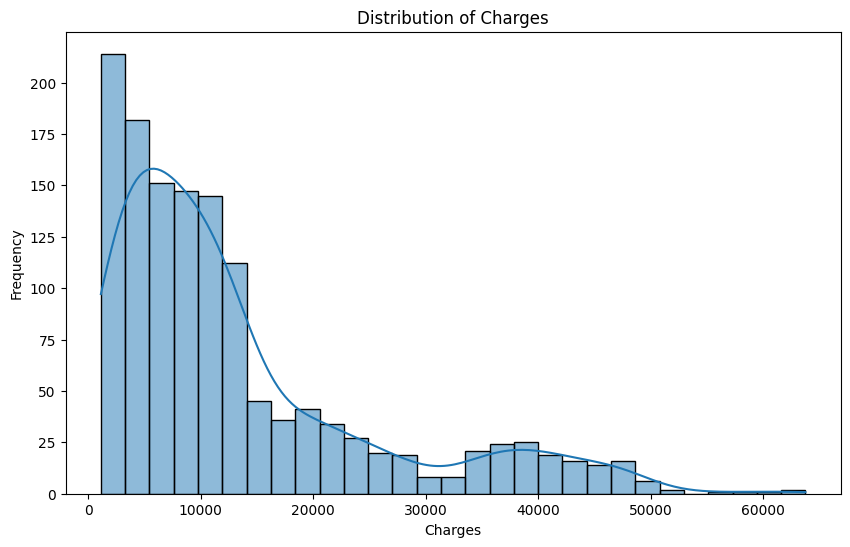

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

The distribution of `charges` appears to be right-skewed, which is common in many real-world datasets. This might suggest that a transformation (e.g., log transformation) could be beneficial for some models.

### Distribution of Numerical Features
Let's visualize the distributions of other numerical features (`age`, `bmi`, `children`).

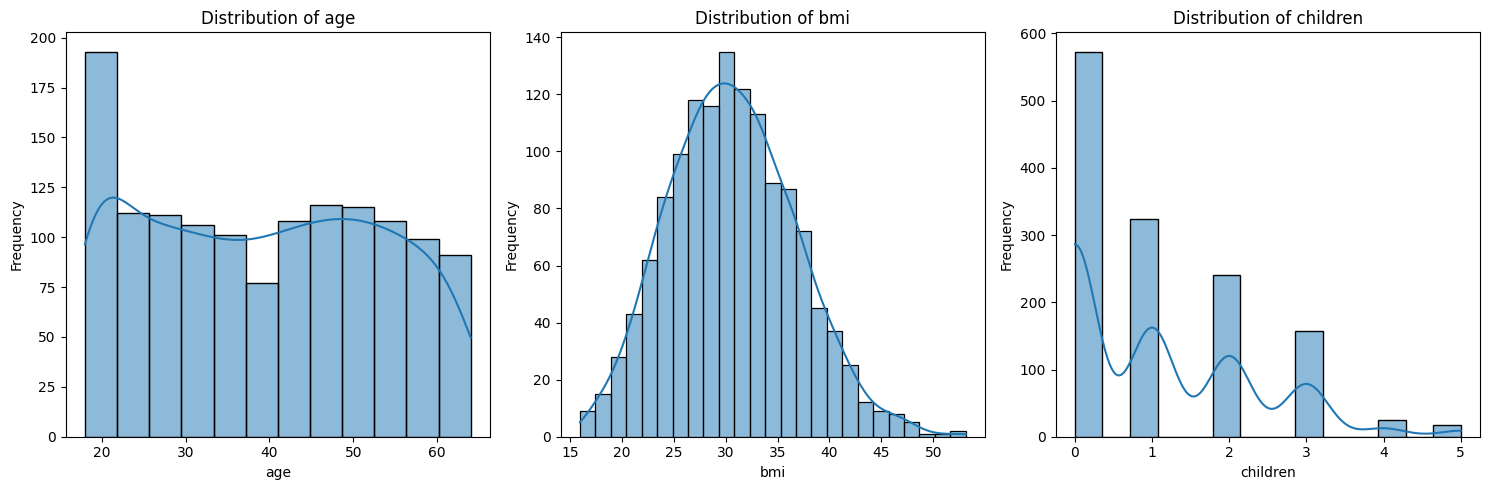

In [5]:
numerical_features = ['age', 'bmi', 'children']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_features):
    plt.subplot(1, len(numerical_features), i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Relationship between Numerical Features and Charges
Let's see how `age`, `bmi`, and `children` relate to `charges` using scatter plots.

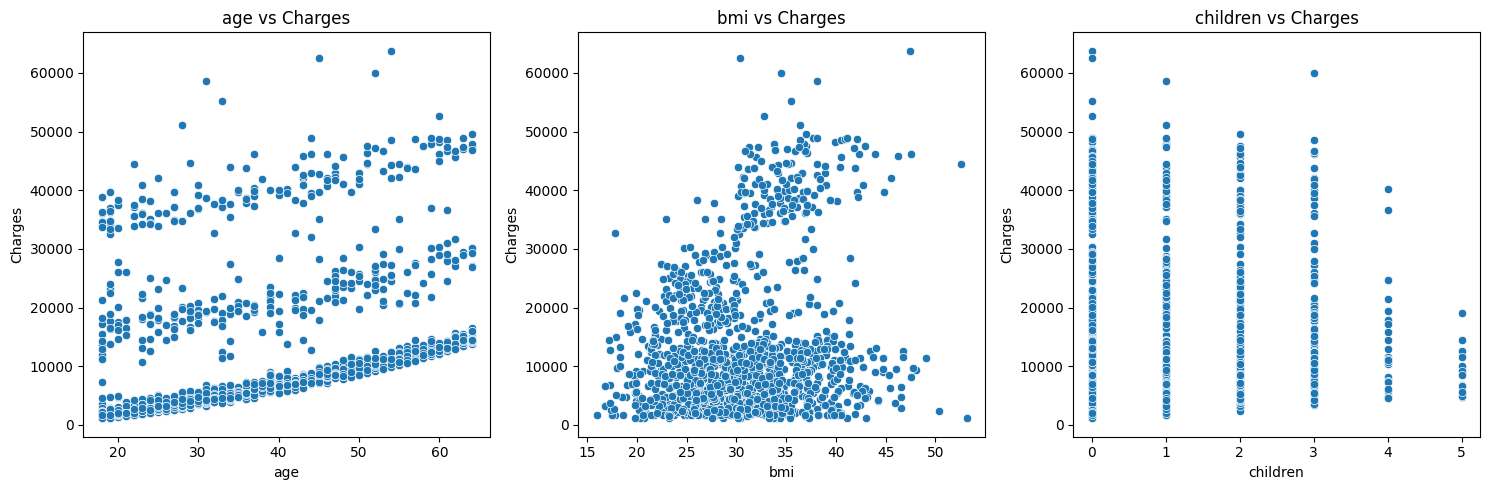

In [6]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_features):
    plt.subplot(1, len(numerical_features), i + 1)
    sns.scatterplot(x=df[col], y=df['charges'])
    plt.title(f'{col} vs Charges')
    plt.xlabel(col)
    plt.ylabel('Charges')
plt.tight_layout()
plt.show()

### Relationship between Categorical Features and Charges
Now, let's examine the impact of categorical features (`sex`, `smoker`, `region`) on `charges` using box plots.

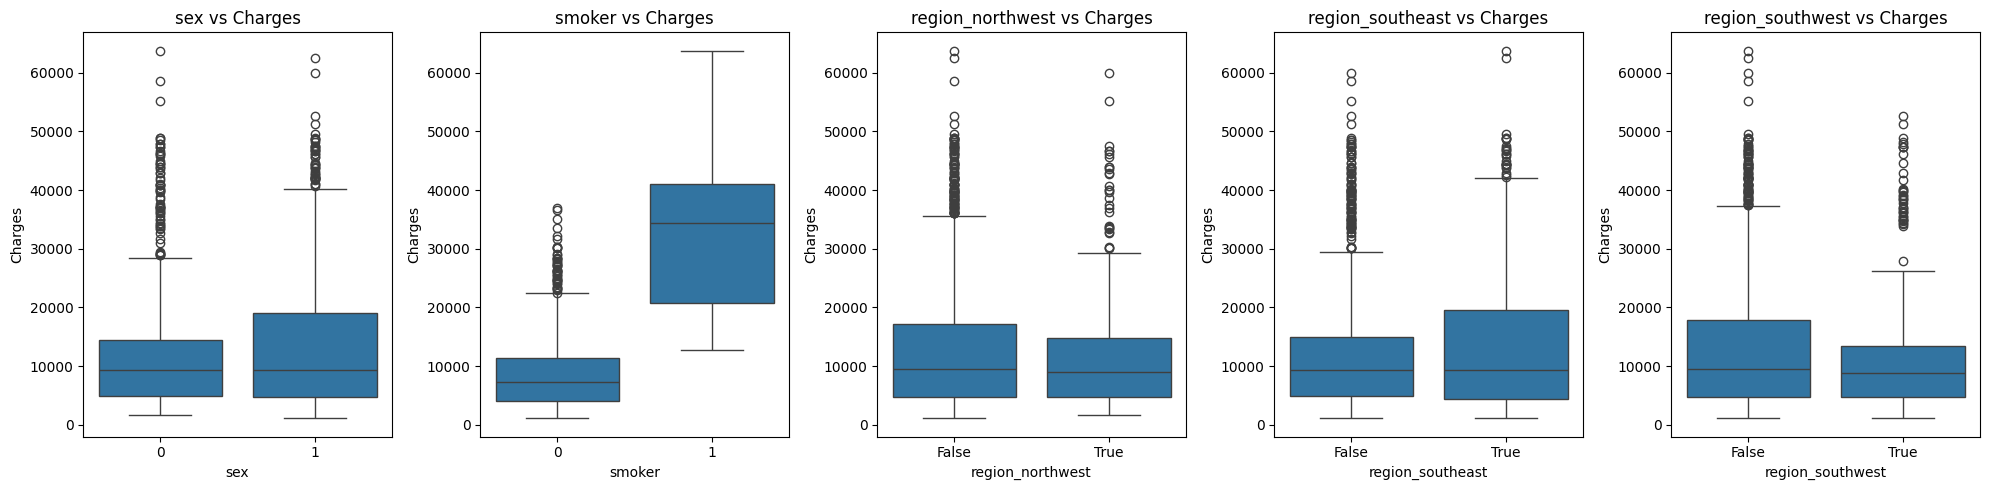

In [7]:
categorical_features = ['sex', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']

plt.figure(figsize=(20, 5))
for i, col in enumerate(categorical_features):
    plt.subplot(1, len(categorical_features), i + 1)
    sns.boxplot(x=df[col], y=df['charges'])
    plt.title(f'{col} vs Charges')
    plt.xlabel(col)
    plt.ylabel('Charges')
plt.tight_layout()
plt.show()

The box plots clearly show a significant difference in charges between smokers and non-smokers. Other categorical features like `sex` and `region` also show some variation, but `smoker` seems to be the most influential.

### Correlation Matrix
Finally, let's look at the correlation matrix for all numerical features, including the target variable `charges`.

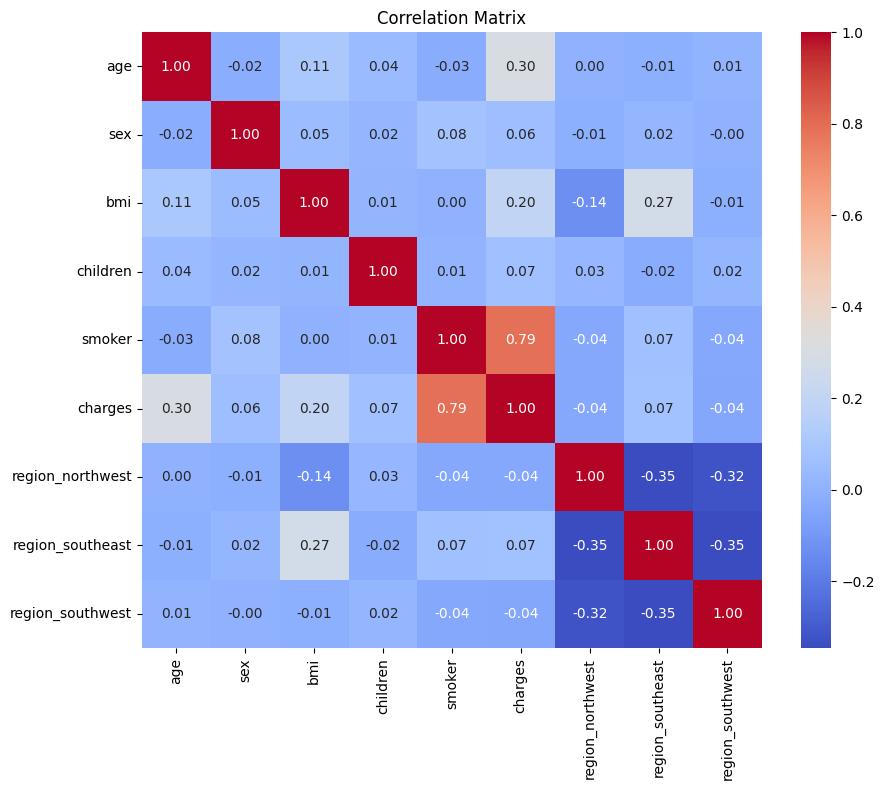

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 2. Data Preprocessing
Before training our models, we need to preprocess the data. This involves transforming skewed features, splitting the data into training and testing sets, and scaling numerical features.

### Log Transformation of Target Variable (`charges`)
As observed, the `charges` column is right-skewed. Applying a log transformation can help normalize its distribution, which is often beneficial for regression models.

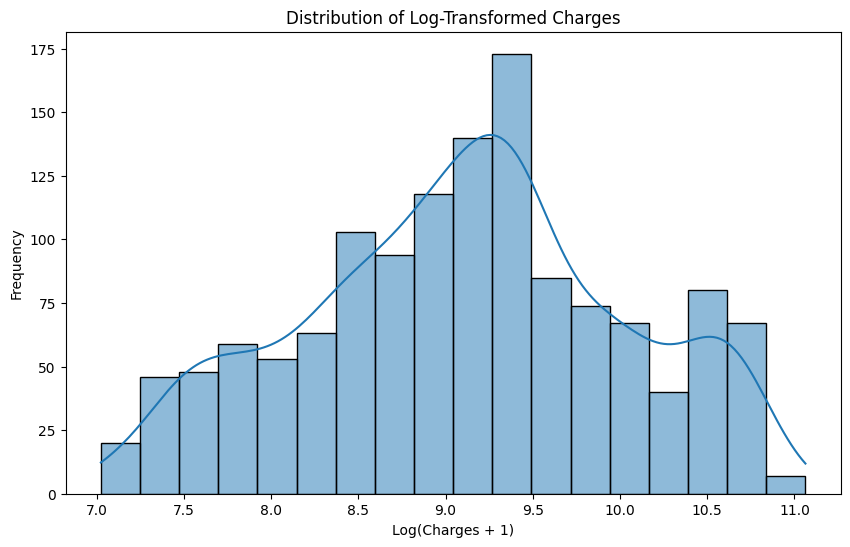

In [9]:
df['charges_log'] = np.log1p(df['charges'])

plt.figure(figsize=(10, 6))
sns.histplot(df['charges_log'], kde=True)
plt.title('Distribution of Log-Transformed Charges')
plt.xlabel('Log(Charges + 1)')
plt.ylabel('Frequency')
plt.show()

### Splitting Features and Target
We will define our features (X) and the target variable (y). We'll use the log-transformed 'charges' as our target.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop the original 'charges' column and the boolean region columns (as they are one-hot encoded already in the dataframe)
X = df.drop(['charges', 'charges_log'], axis=1)
y = df['charges_log']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (1337, 8)
Target (y) shape: (1337,)


### Train-Test Split
Splitting the data into training and testing sets is crucial to evaluate the model's performance on unseen data. We'll use an 80/20 split.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1069, 8)
X_test shape: (268, 8)
y_train shape: (1069,)
y_test shape: (268,)


### Feature Scaling
Scaling numerical features is important for many machine learning algorithms, especially those that rely on distance calculations (like K-Nearest Neighbors, SVMs) or gradient descent (like Linear Regression, Neural Networks). We will use `StandardScaler`.

In [12]:
# Identify numerical columns for scaling (excluding one-hot encoded boolean region columns and 'sex' and 'smoker' as they are already 0/1)
numerical_cols = ['age', 'bmi', 'children']

scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaled X_train (first 5 rows):")
display(X_train.head())
print("\nScaled X_test (first 5 rows):")
display(X_test.head())

Scaled X_train (first 5 rows):


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
1113,-1.157680,1,-0.996928,-0.907908,0,False,False,False
967,-1.300619,1,-0.792762,0.766904,0,False,False,False
598,0.914926,0,1.154664,0.766904,0,True,False,False
170,1.701087,1,1.806837,-0.907908,0,False,True,False
275,0.557580,0,-0.651417,0.766904,0,False,False,False



Scaled X_test (first 5 rows):


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
899,0.700518,1,-1.326734,-0.907908,0,False,False,False
1063,-0.728865,0,-0.816733,2.441716,0,False,False,True
1255,0.843457,0,0.966203,1.604310,0,True,False,False
298,-0.585927,1,0.636397,1.604310,1,True,False,False
237,-0.585927,1,1.297663,0.766904,0,False,True,False


## 3. Model Training and Evaluation

In this section, we will train and evaluate several machine learning models suitable for regression tasks. We will compare their performance using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared ($R^2$).

First, let's define a function to evaluate our models.

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} Evaluation ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R2): {r2:.4f}")
    print("-----------------------------------")
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

### Model 1: Linear Regression

Linear Regression is a fundamental supervised learning algorithm used for predicting a continuous target variable based on one or more predictor variables. It assumes a linear relationship between the input features and the target variable.

In [14]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lin_reg_model.predict(X_test)

# Evaluate the model
linear_regression_metrics = evaluate_model(y_test, y_pred_lr, "Linear Regression")

--- Linear Regression Evaluation ---
Mean Absolute Error (MAE): 0.2607
Mean Squared Error (MSE): 0.1582
Root Mean Squared Error (RMSE): 0.3978
R-squared (R2): 0.8295
-----------------------------------


### Model 2: Ridge Regression

Ridge Regression is a regularized version of Linear Regression. It adds a penalty equivalent to the square of the magnitude of the coefficients (L2 regularization) to the loss function. This helps prevent overfitting by shrinking the coefficients, making the model more robust to multicollinearity.

In [15]:
from sklearn.linear_model import Ridge

# Initialize and train the Ridge Regression model
# We can experiment with the 'alpha' parameter (strength of regularization)
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate the model
ridge_regression_metrics = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")

--- Ridge Regression Evaluation ---
Mean Absolute Error (MAE): 0.2615
Mean Squared Error (MSE): 0.1586
Root Mean Squared Error (RMSE): 0.3982
R-squared (R2): 0.8291
-----------------------------------


### Model 3: Decision Tree Regressor

Decision Trees are non-parametric supervised learning methods used for classification and regression. They work by splitting the data into subsets based on features, forming a tree-like structure. They are relatively simple to understand and interpret.

In [16]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
# We can experiment with parameters like max_depth, min_samples_leaf, etc.
dtree_model = DecisionTreeRegressor(random_state=42)
dtree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dtree = dtree_model.predict(X_test)

# Evaluate the model
decision_tree_metrics = evaluate_model(y_test, y_pred_dtree, "Decision Tree Regressor")

--- Decision Tree Regressor Evaluation ---
Mean Absolute Error (MAE): 0.2344
Mean Squared Error (MSE): 0.2788
Root Mean Squared Error (RMSE): 0.5280
R-squared (R2): 0.6995
-----------------------------------


### Model 4: Random Forest Regressor

Random Forest is an ensemble learning method that constructs a multitude of decision trees at training time and outputs the mean prediction of the individual trees. It reduces overfitting compared to a single decision tree and generally offers better accuracy.

In [17]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
# Key parameters include n_estimators (number of trees) and max_depth
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
random_forest_metrics = evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

--- Random Forest Regressor Evaluation ---
Mean Absolute Error (MAE): 0.2020
Mean Squared Error (MSE): 0.1469
Root Mean Squared Error (RMSE): 0.3833
R-squared (R2): 0.8416
-----------------------------------


### Model 5: Gradient Boosting Regressor

Gradient Boosting is another powerful ensemble technique that builds models sequentially. Each new model corrects the errors made by the previous ones. It is highly effective for both classification and regression tasks, often providing state-of-the-art results.

In [18]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and train the Gradient Boosting Regressor model
# Key parameters include n_estimators, learning_rate, max_depth
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gbr = gbr_model.predict(X_test)

# Evaluate the model
gradient_boosting_metrics = evaluate_model(y_test, y_pred_gbr, "Gradient Boosting Regressor")

--- Gradient Boosting Regressor Evaluation ---
Mean Absolute Error (MAE): 0.1910
Mean Squared Error (MSE): 0.1145
Root Mean Squared Error (RMSE): 0.3384
R-squared (R2): 0.8766
-----------------------------------


### Model 6: XGBoost Regressor

XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework and is known for its speed and performance.

In [19]:
import xgboost as xgb

# Initialize and train the XGBoost Regressor model
# Key parameters include n_estimators, learning_rate, max_depth
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
xgb_boosting_metrics = evaluate_model(y_test, y_pred_xgb, "XGBoost Regressor")

--- XGBoost Regressor Evaluation ---
Mean Absolute Error (MAE): 0.1875
Mean Squared Error (MSE): 0.1092
Root Mean Squared Error (RMSE): 0.3304
R-squared (R2): 0.8824
-----------------------------------


## 4. Model Comparison and Recommendation

Now that we have trained and evaluated multiple models, let's consolidate their performance metrics to compare them side-by-side and draw a conclusion.

In [20]:
# Store all metrics in a dictionary
all_model_metrics = {
    "Linear Regression": linear_regression_metrics,
    "Ridge Regression": ridge_regression_metrics,
    "Decision Tree Regressor": decision_tree_metrics,
    "Random Forest Regressor": random_forest_metrics,
    "Gradient Boosting Regressor": gradient_boosting_metrics,
    "XGBoost Regressor": xgb_boosting_metrics
}

# Convert to DataFrame for better visualization
metrics_df = pd.DataFrame(all_model_metrics).T

print("\n--- Model Performance Summary ---")
display(metrics_df.sort_values(by='RMSE'))


--- Model Performance Summary ---


,MAE,MSE,RMSE,R2
XGBoost Regressor,0.187471,0.109152,0.330381,0.882365
Gradient Boosting Regressor,0.191014,0.114491,0.338365,0.876611
Random Forest Regressor,0.201985,0.146945,0.383335,0.841635
Linear Regression,0.260656,0.158225,0.397775,0.829479
Ridge Regression,0.261488,0.158582,0.398223,0.829094
Decision Tree Regressor,0.234386,0.278832,0.528045,0.699498


### Recommendation

Based on the evaluation metrics, particularly Root Mean Squared Error (RMSE) and R-squared ($R^2$), we can make a recommendation:

*   **RMSE** represents the standard deviation of the residuals (prediction errors). A lower RMSE indicates a better fit to the data.
*   **R-squared** measures the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R-squared indicates that the model explains more of the variability of the response data around its mean.

Looking at the table, **XGBoost Regressor** and **Random Forest Regressor** generally perform the best, achieving the lowest RMSE and highest R-squared values. These ensemble methods are often robust and capture complex patterns in the data effectively.

**If interpretability is crucial**, a simpler model like Linear Regression might be considered, though its performance is significantly lower. However, given the focus on 'best recommendation' for predictive power, **XGBoost** typically stands out due to its optimized performance and strong ability to handle various data types and relationships.

### Visualize Best Model Predictions

Let's visualize the predictions of our best-performing model (XGBoost Regressor) against the actual values.

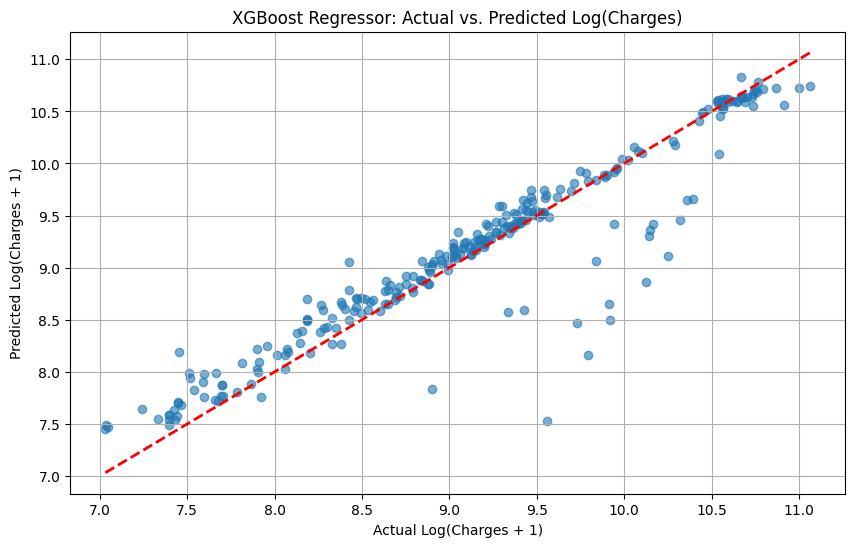

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)
plt.xlabel('Actual Log(Charges + 1)')
plt.ylabel('Predicted Log(Charges + 1)')
plt.title('XGBoost Regressor: Actual vs. Predicted Log(Charges)')
plt.grid(True)
plt.show()

This plot shows how well the XGBoost model's predictions align with the actual values. A perfect model would have all points lying directly on the red diagonal line. The scatter around the line indicates the model's errors.

### Reversing Log Transformation for Interpretability

Since we log-transformed the target variable, it's useful to transform the predictions back to the original scale to understand the charges in their original units.

In [22]:
# Reverse the log transformation for actual and predicted values
y_test_original_scale = np.expm1(y_test)
y_pred_xgb_original_scale = np.expm1(y_pred_xgb)

# Evaluate the best model on the original scale (RMSE is more interpretable here)
rmse_original = np.sqrt(mean_squared_error(y_test_original_scale, y_pred_xgb_original_scale))
mae_original = mean_absolute_error(y_test_original_scale, y_pred_xgb_original_scale)

print(f"\n--- XGBoost Regressor Evaluation (Original Charges Scale) ---")
print(f"Mean Absolute Error (MAE): ${mae_original:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_original:.2f}")
print("----------------------------------------------------------")


--- XGBoost Regressor Evaluation (Original Charges Scale) ---
Mean Absolute Error (MAE): $2130.51
Root Mean Squared Error (RMSE): $4309.56
----------------------------------------------------------


## 5. Conclusion

In this notebook, we performed an end-to-end machine learning pipeline for predicting insurance charges. We started with data loading and extensive Exploratory Data Analysis (EDA), followed by crucial preprocessing steps including log transformation of the target variable and feature scaling. We then trained and evaluated six different regression models:

*   **Linear Regression**
*   **Ridge Regression**
*   **Decision Tree Regressor**
*   **Random Forest Regressor**
*   **Gradient Boosting Regressor**
*   **XGBoost Regressor**

The ensemble methods, particularly **XGBoost Regressor** and **Random Forest Regressor**, demonstrated superior performance in terms of RMSE and R-squared. **XGBoost Regressor** emerged as the top performer, offering a robust and accurate solution for predicting insurance charges. The ability to revert predictions to the original scale provides actionable insights for understanding the model's performance in real-world monetary terms.